## 14. Conclusion

This project explored different factors influencing student performance using Python for data analysis and visualization.

The analysis showed that study hours, attendance, internet access, parental education, and extracurricular activities have a noticeable impact on academic performance.

The visualizations made it easier to understand patterns and relationships in the dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [ ]:
primary = "#4C72B0"
secondary = "#55A868"
danger = "#C44E52"
warning = "#F39C12"

palette = [primary, secondary, warning, danger]
sns.set_palette(palette)

## 1. Loading the Dataset

Before performing any analysis, we first load the dataset and understand its structure, number of rows, columns, and data types.

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

df = pd.DataFrame({
    "Gender": np.random.choice(["Male", "Female"], n),
    "Study_Hours": np.round(np.random.uniform(1, 10, n), 1),
    "Attendance": np.random.randint(60, 101, n),
    "Internet_Access": np.random.choice(["Yes", "No"], n),
    "Parental_Education": np.random.choice(
        ["High School", "Bachelor", "Master", "PhD"], n
    ),
    "Extracurricular": np.random.choice(["Yes", "No"], n)
})

df["Exam_Score"] = (
    25
    + df["Study_Hours"] * 5
    + df["Attendance"] * 0.35
    + np.random.normal(0, 5, n)
)

df["Exam_Score"] = df["Exam_Score"].clip(35, 100).round().astype(int)

print(df.head())

   Gender  Study_Hours  Attendance Internet_Access Parental_Education  \
0    Male          1.3          91              No             Master   
1  Female          6.7          89              No             Master   
2    Male          3.8          94              No        High School   
3    Male          5.6          99              No        High School   
4    Male          9.2          75              No           Bachelor   

  Extracurricular  Exam_Score  
0              No          66  
1              No          98  
2              No          82  
3              No          91  
4             Yes          95  


In [ ]:
print("First Five Records")
df.head()

First Five Records


,Gender,Study_Hours,Attendance,Internet_Access,Parental_Education,Extracurricular,Exam_Score
0,Male,1.3,91,No,Master,No,66
1,Female,6.7,89,No,Master,No,98
2,Male,3.8,94,No,High School,No,82
3,Male,5.6,99,No,High School,No,91
4,Male,9.2,75,No,Bachelor,Yes,95


In [ ]:
print("Summary Statistics")
df.describe()

Summary Statistics


,Study_Hours,Attendance,Exam_Score
count,200.000000,200.000000,200.000000
mean,5.570000,80.890000,80.895000
std,2.636524,11.569667,13.842037
min,1.000000,60.000000,53.000000
25%,3.200000,71.000000,70.000000
50%,5.700000,82.000000,81.000000
75%,7.900000,91.000000,94.000000
max,9.900000,100.000000,100.000000


In [ ]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df)) * 100
})

missing_df

,Missing Values,Percentage
Gender,0,0.0
Study_Hours,0,0.0
Attendance,0,0.0
Internet_Access,0,0.0
Parental_Education,0,0.0
Extracurricular,0,0.0
Exam_Score,0,0.0


## 2. Understanding Student Characteristics

Now we will explore the distribution of gender, attendance, and study habits to understand the overall student population.

Gender
Male      100
Female    100
Name: count, dtype: int64


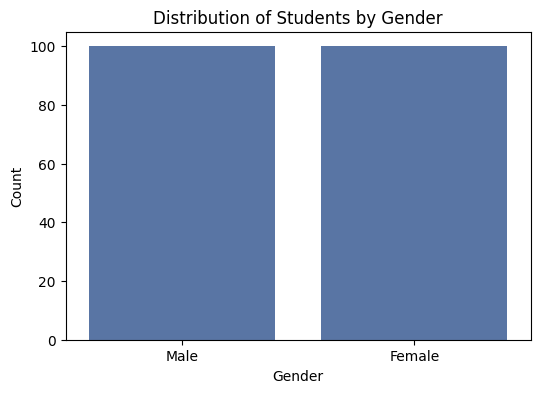

In [ ]:
gender = df["Gender"].value_counts()

print(gender)

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Gender")

plt.title("Distribution of Students by Gender")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

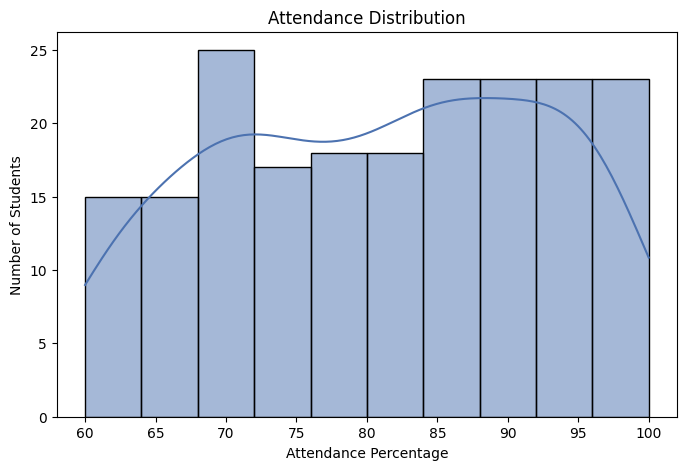

In [ ]:
attendance = df["Attendance"]

plt.figure(figsize=(8,5))

sns.histplot(attendance, bins=10, kde=True)

plt.title("Attendance Distribution")

plt.xlabel("Attendance Percentage")

plt.ylabel("Number of Students")

plt.show()

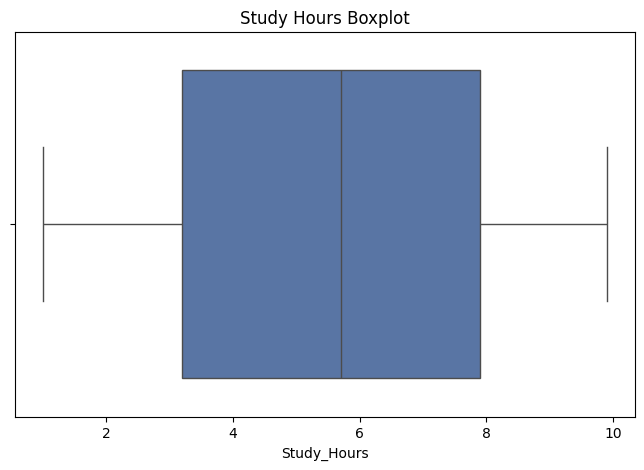

In [ ]:
study = df["Study_Hours"]

plt.figure(figsize=(8,5))

sns.boxplot(x=study)

plt.title("Study Hours Boxplot")

plt.show()

## 3. Relationship Between Study Hours and Exam Score

Now we will check whether students who study more tend to score higher in exams.

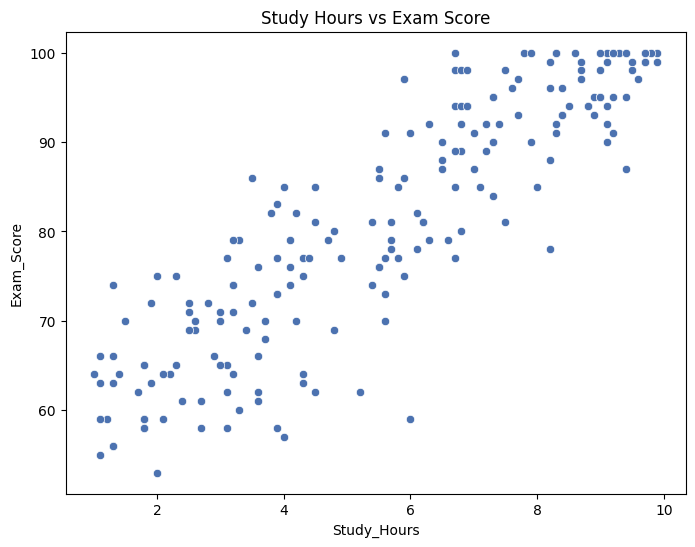

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x="Study_Hours",
                y="Exam_Score")

plt.title("Study Hours vs Exam Score")

plt.show()

In [ ]:
correlation = df["Study_Hours"].corr(df["Exam_Score"])

print("Correlation:", correlation)

Correlation: 0.8862225124172415


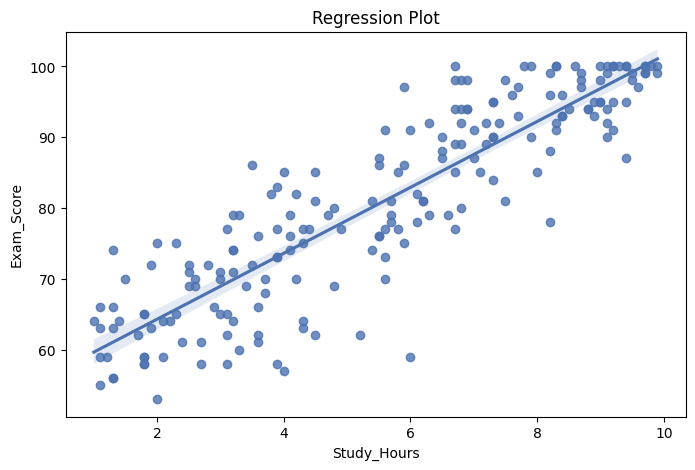

In [ ]:
plt.figure(figsize=(8,5))

sns.regplot(data=df,
            x="Study_Hours",
            y="Exam_Score")

plt.title("Regression Plot")

plt.show()

## 4. Correlation Between Numerical Variables

Now we will calculate the correlation among all numerical features using a heatmap.

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

corr_matrix

,Study_Hours,Attendance,Exam_Score
Study_Hours,1.000000,-0.036417,0.886223
Attendance,-0.036417,1.000000,0.247375
Exam_Score,0.886223,0.247375,1.000000


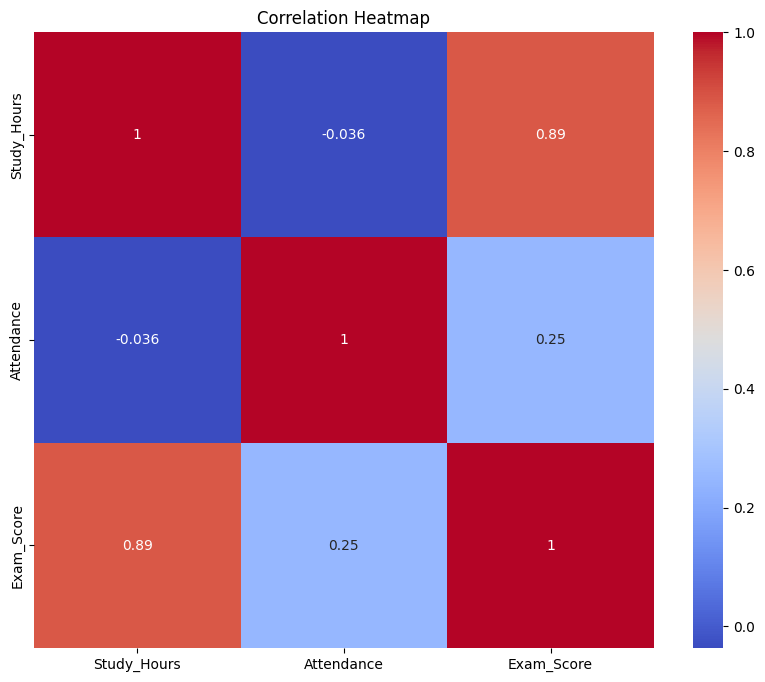

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
top_students = df.sort_values(by="Exam_Score", ascending=False)

top_students.head(10)

,Gender,Study_Hours,Attendance,Internet_Access,Parental_Education,Extracurricular,Exam_Score
7,Male,7.8,78,Yes,Master,Yes,100
20,Female,8.3,91,Yes,Master,No,100
54,Male,9.9,95,Yes,Master,No,100
50,Male,9.2,96,Yes,Bachelor,No,100
21,Male,9.1,84,No,Master,Yes,100
14,Female,6.7,82,Yes,Bachelor,Yes,100
12,Male,9.4,96,No,Bachelor,Yes,100
82,Male,9.3,69,No,Master,Yes,100
147,Male,9.7,94,Yes,Master,Yes,100
148,Male,9.7,71,Yes,Master,Yes,100


## 5. Average Exam Score by Gender

In this section, we will compare the average exam scores of male and female students.

In [ ]:
gender_score = df.groupby("Gender")["Exam_Score"].mean()

print(gender_score)

Gender
Female    80.12
Male      81.67
Name: Exam_Score, dtype: float64


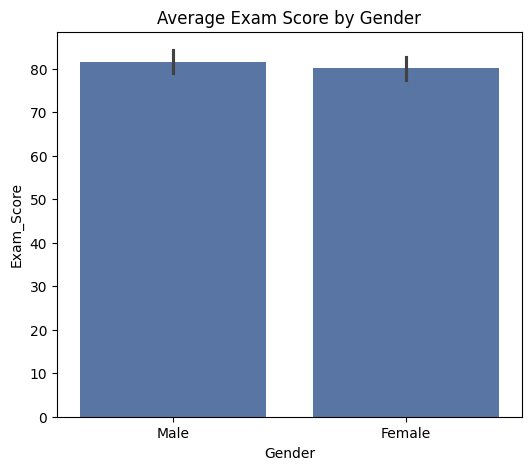

In [ ]:
plt.figure(figsize=(6,5))

sns.barplot(data=df,
            x="Gender",
            y="Exam_Score",
            estimator=np.mean)

plt.title("Average Exam Score by Gender")

plt.show()

## 6. Attendance vs Exam Score

Now we will study whether higher attendance leads to better exam performance.

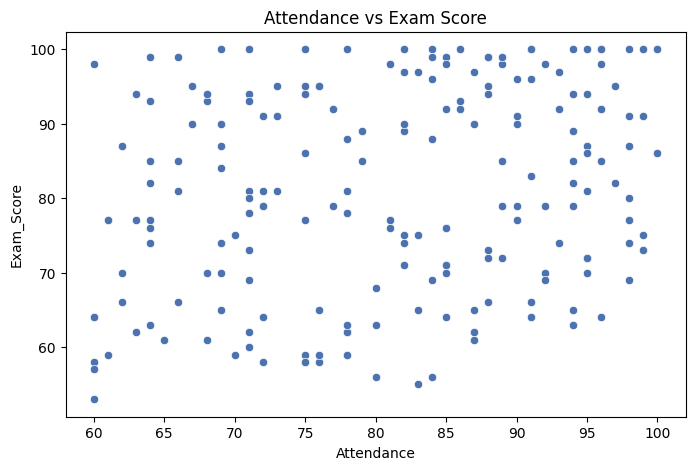

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x="Attendance",
                y="Exam_Score")

plt.title("Attendance vs Exam Score")

plt.show()

In [ ]:
attendance_corr = df["Attendance"].corr(df["Exam_Score"])

print("Attendance Correlation:", attendance_corr)

Attendance Correlation: 0.24737489056220893


## 7. Internet Access Analysis

We will compare the performance of students who have internet access and those who do not.

In [ ]:
internet_score = df.groupby("Internet_Access")["Exam_Score"].mean()

print(internet_score)

Internet_Access
No     80.774194
Yes    81.000000
Name: Exam_Score, dtype: float64


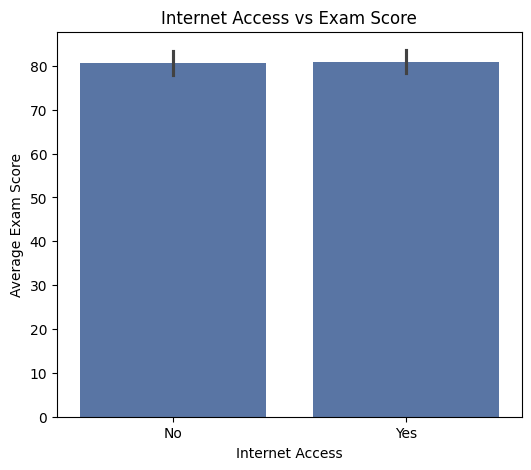

In [ ]:
plt.figure(figsize=(6,5))

sns.barplot(data=df,
            x="Internet_Access",
            y="Exam_Score")

plt.title("Internet Access vs Exam Score")

plt.xlabel("Internet Access")

plt.ylabel("Average Exam Score")

plt.show()

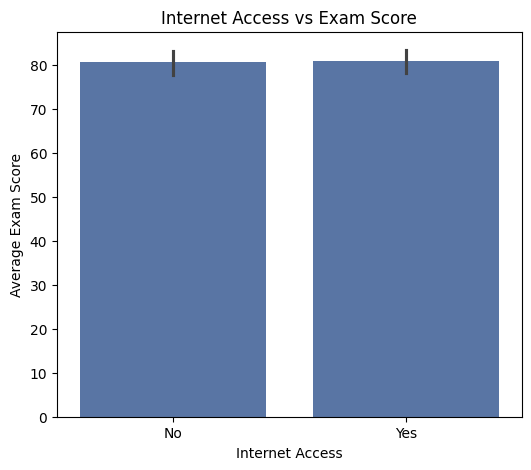

In [ ]:
plt.figure(figsize=(6,5))

sns.barplot(data=df,
            x="Internet_Access",
            y="Exam_Score")

plt.title("Internet Access vs Exam Score")

plt.xlabel("Internet Access")

plt.ylabel("Average Exam Score")

plt.show()

## 8. Parental Education Analysis

In this section, we will analyze whether the education level of parents affects students' exam performance.

In [ ]:
parent_score = df.groupby("Parental_Education")["Exam_Score"].mean()

print(parent_score)

Parental_Education
Bachelor       81.589286
High School    81.020833
Master         81.072727
PhD            79.560976
Name: Exam_Score, dtype: float64


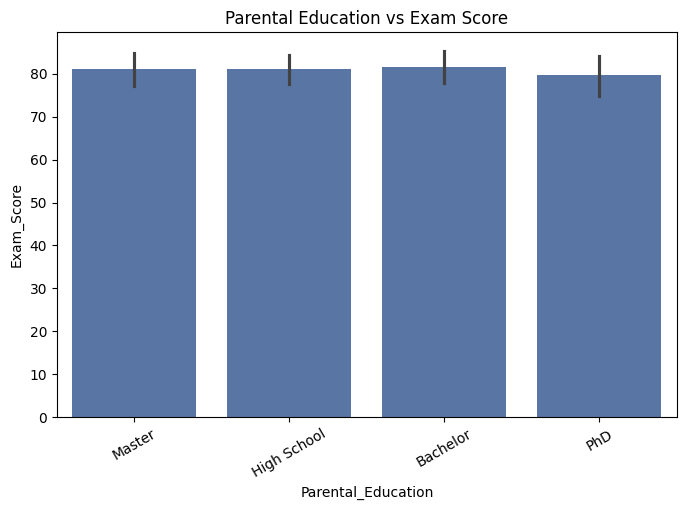

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(data=df,
            x="Parental_Education",
            y="Exam_Score")

plt.title("Parental Education vs Exam Score")

plt.xticks(rotation=30)

plt.show()

## 9. Extracurricular Activities

Now we will compare the academic performance of students who participate in extracurricular activities with those who do not.

In [ ]:
activity_score = df.groupby("Extracurricular")["Exam_Score"].mean()

print(activity_score)

Extracurricular
No     80.28
Yes    81.51
Name: Exam_Score, dtype: float64


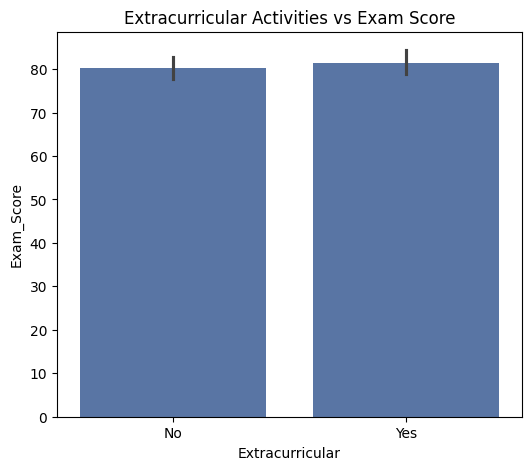

In [ ]:
plt.figure(figsize=(6,5))

sns.barplot(data=df,
            x="Extracurricular",
            y="Exam_Score")

plt.title("Extracurricular Activities vs Exam Score")

plt.show()

## 10. Performance Categories

Students will now be classified into different performance levels based on their exam scores.

In [ ]:
def performance(score):
    if score >= 85:
        return "Excellent"
    elif score >= 70:
        return "Good"
    elif score >= 50:
        return "Average"
    else:
        return "Poor"

df["Performance"] = df["Exam_Score"].apply(performance)

df.head()

,Gender,Study_Hours,Attendance,Internet_Access,Parental_Education,Extracurricular,Exam_Score,Performance
0,Male,1.3,91,No,Master,No,66,Average
1,Female,6.7,89,No,Master,No,98,Excellent
2,Male,3.8,94,No,High School,No,82,Good
3,Male,5.6,99,No,High School,No,91,Excellent
4,Male,9.2,75,No,Bachelor,Yes,95,Excellent


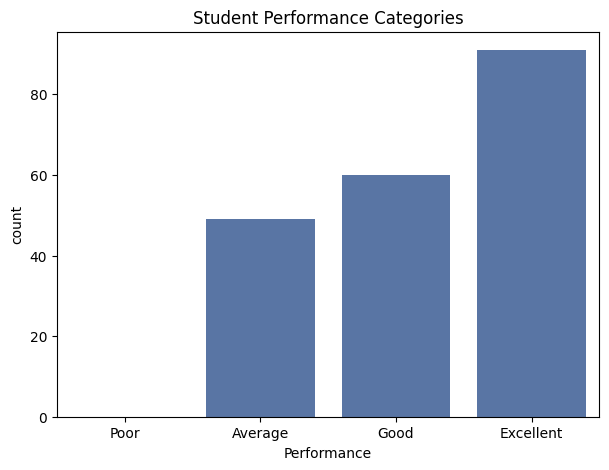

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x="Performance",
              order=["Poor","Average","Good","Excellent"])

plt.title("Student Performance Categories")

plt.show()

In [ ]:
performance_count = df["Performance"].value_counts()

print(performance_count)

Performance
Excellent    91
Good         60
Average      49
Name: count, dtype: int64


## 11. Pair Plot Analysis

A pair plot helps visualize the relationship between multiple numerical variables simultaneously.

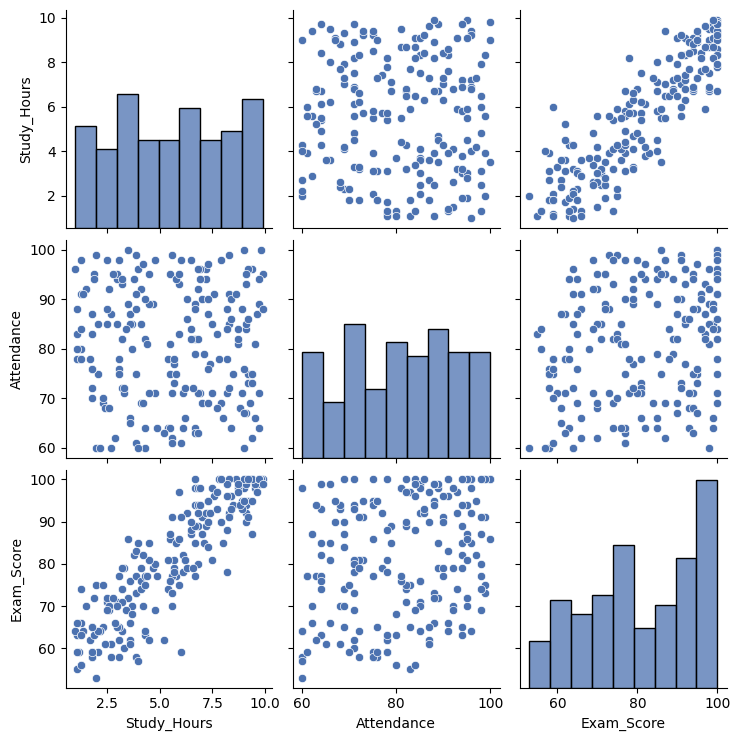

In [ ]:
sns.pairplot(df[["Study_Hours",
                 "Attendance",
                 "Exam_Score"]])

plt.show()

## 12. Distribution of Exam Scores

Let's observe how exam scores are distributed among students.

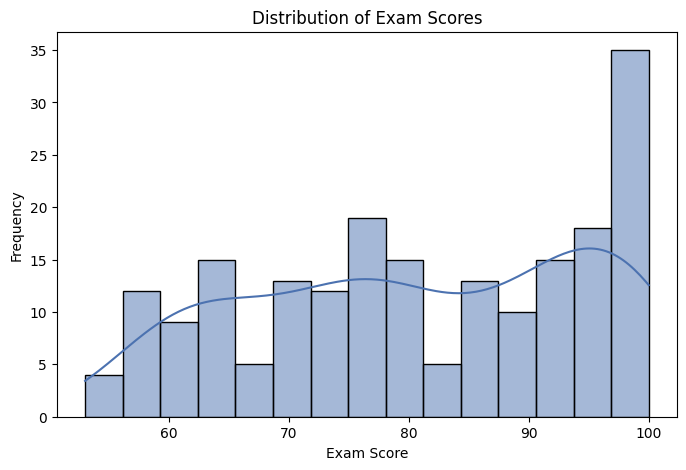

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Exam_Score"],
             bins=15,
             kde=True)

plt.title("Distribution of Exam Scores")

plt.xlabel("Exam Score")

plt.ylabel("Frequency")

plt.show()

In [ ]:
highest = df.nlargest(5, "Exam_Score")

highest

,Gender,Study_Hours,Attendance,Internet_Access,Parental_Education,Extracurricular,Exam_Score,Performance
7,Male,7.8,78,Yes,Master,Yes,100,Excellent
12,Male,9.4,96,No,Bachelor,Yes,100,Excellent
14,Female,6.7,82,Yes,Bachelor,Yes,100,Excellent
20,Female,8.3,91,Yes,Master,No,100,Excellent
21,Male,9.1,84,No,Master,Yes,100,Excellent


In [ ]:
highest = df.nlargest(5, "Exam_Score")

highest

,Gender,Study_Hours,Attendance,Internet_Access,Parental_Education,Extracurricular,Exam_Score,Performance
7,Male,7.8,78,Yes,Master,Yes,100,Excellent
12,Male,9.4,96,No,Bachelor,Yes,100,Excellent
14,Female,6.7,82,Yes,Bachelor,Yes,100,Excellent
20,Female,8.3,91,Yes,Master,No,100,Excellent
21,Male,9.1,84,No,Master,Yes,100,Excellent


## 13. Key Findings

After analyzing the dataset, we observed several important patterns that explain student performance.

In [ ]:
print("Key Findings")

print("- Students with higher study hours generally scored better.")

print("- Higher attendance showed a positive relationship with exam scores.")

print("- Students with internet access performed slightly better.")

print("- Students participating in extracurricular activities also performed well.")

print("- Performance categories helped classify students easily.")

Key Findings
- Students with higher study hours generally scored better.
- Higher attendance showed a positive relationship with exam scores.
- Students with internet access performed slightly better.
- Students participating in extracurricular activities also performed well.
- Performance categories helped classify students easily.


## 14. Conclusion

This project explored different factors influencing student performance using Python for data analysis and visualization.

The analysis showed that study hours, attendance, internet access, parental education, and extracurricular activities have a noticeable impact on academic performance.

The visualizations made it easier to understand patterns and relationships in the dataset.